# Digital Twin Augsburg – Georgsvorstadt
## Explorative Datenanalyse

Dieses Notebook visualisiert die Gebäudedaten des Quartiers und gibt einen Überblick über
Höhenverteilung, Datenquellen (CityGML / OSM / Fallback), Nutzungsklassen, Dachformen,
Adressen, Denkmalschutz, Wikidata-Anreicherung und Solarpotenzial (PVGIS).

In [11]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

from configs.settings import BUILDINGS_GEOJSON, DATA_INTERIM

In [12]:
# Bereinigtes GeoJSON laden (nach Phase 2) – Wikidata-Anreicherung bevorzugen, falls vorhanden (Phase 8)
wikidata_path = DATA_INTERIM / 'georgsvorstadt_clean_wikidata.geojson'
clean_path    = DATA_INTERIM / 'georgsvorstadt_clean.geojson'
geojson_path  = wikidata_path if wikidata_path.exists() else clean_path

gdf = gpd.read_file(geojson_path)
gdf_metric = gdf.to_crs('EPSG:25832')

print(f'Quelle           : {geojson_path.name}')
print(f'Gebäude gesamt   : {len(gdf)}')
print(f'CRS              : {gdf.crs}')
print(f'Spalten          : {list(gdf.columns)}')
print()
# Höhenquellen-Übersicht
if 'height_source' in gdf.columns:
    print('Höhenquellen:')
    print(gdf['height_source'].value_counts().to_string())
gdf.head(3)

Quelle           : georgsvorstadt_clean_wikidata.geojson
Gebäude gesamt   : 2139
CRS              : EPSG:4326
Spalten          : ['osm_id', 'name', 'building', 'levels', 'height', 'start_date', 'addr_street', 'addr_housenumber', 'addr_postcode', 'addr_city', 'osm_roof_shape', 'osm_roof_colour', 'osm_roof_material', 'osm_roof_levels', 'osm_roof_orientation', 'osm_roof_direction', 'osm_roof_height', 'building_colour', 'building_material', 'building_architecture', 'heritage', 'heritage_operator', 'ref_blfd', 'blfd_criteria', 'wikidata', 'wikipedia', 'architect', 'amenity', 'historic', 'tourism', 'religion', 'operator', 'height_osm', 'height_citygml', 'gml_id', 'roof_type', 'height_m', 'height_source', 'wd_baujahr', 'wd_architekt', 'wd_stil', 'wd_denkmal', 'wd_name', 'geometry']

Höhenquellen:
height_source
citygml    1870
osm_tag     171
default      98


,osm_id,name,building,levels,height,start_date,addr_street,addr_housenumber,addr_postcode,addr_city,...,gml_id,roof_type,height_m,height_source,wd_baujahr,wd_architekt,wd_stil,wd_denkmal,wd_name,geometry
0,13712047,Gebäude J,university,4,,,Friedberger Straße,2a,86161,Augsburg,...,None,Flachdach,12.80,osm_tag,,,,,,"POLYGON ((10.90653 48.35837, 10.90664 48.35829..."
1,13712048,Gebäude K,college,3,,1770/72,Friedberger Straße,2,86161,Augsburg,...,None,Flachdach,9.60,osm_tag,,,,Baudenkmal in Bayern,Baudenkmal D-7-61-000-261 in Augsburg im Ortst...,"POLYGON ((10.90692 48.3589, 10.90677 48.35898,..."
2,23576085,,hotel,,,,,,,,...,DEBY_LOD2_107558772,Flachdach,3.58,citygml,,,,,,"POLYGON ((10.8989 48.36532, 10.89891 48.36532,..."


## 1 · Karte der Gebäudegrundrisse

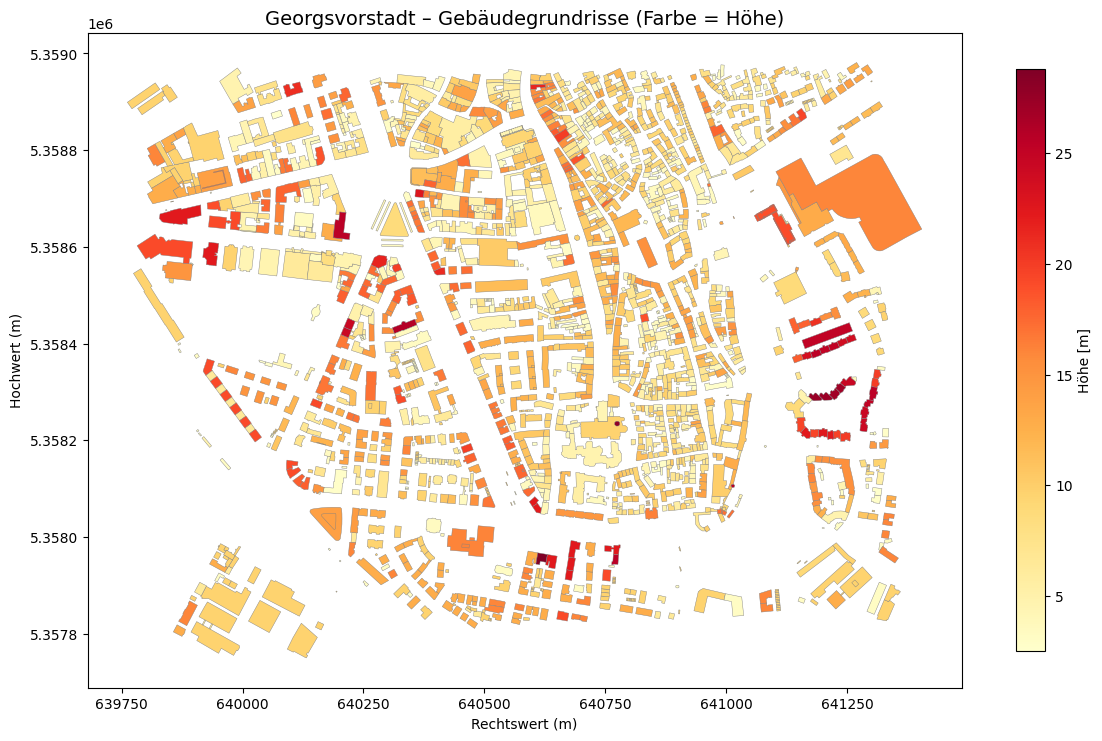

In [13]:
fig, ax = plt.subplots(figsize=(12, 10))

gdf_metric.plot(
    ax=ax,
    column='height_m',
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': 'Höhe [m]', 'shrink': 0.6},
    edgecolor='grey',
    linewidth=0.3,
)

ax.set_title('Georgsvorstadt – Gebäudegrundrisse (Farbe = Höhe)', fontsize=14)
ax.set_xlabel('Rechtswert (m)')
ax.set_ylabel('Hochwert (m)')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(DATA_INTERIM.parent / 'output' / 'map_heights.png', dpi=150)
plt.show()

## 2 · Höhenverteilung & Datenquellen

Höhenquellen:
  BayernAtlas LoD2         :  1870  (87%)
  OSM-Tag                  :   171  (8%)
  Fallback (kein Tag)      :    98  (5%)


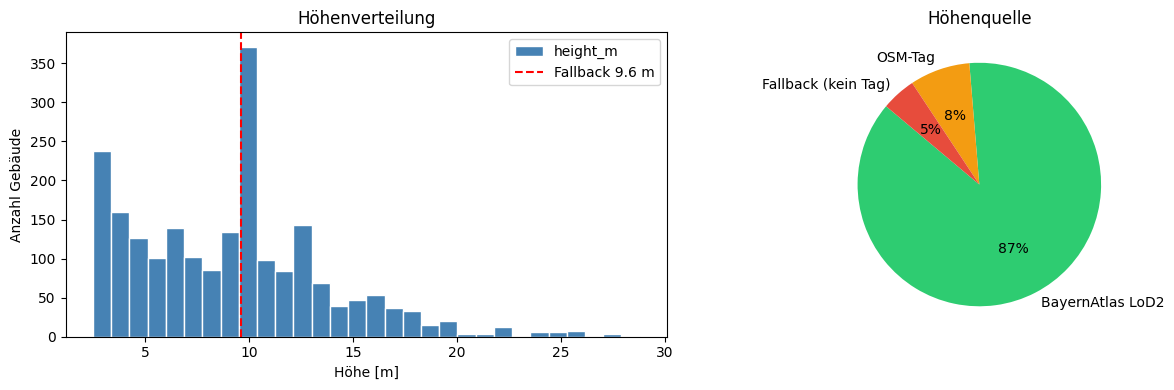

In [14]:
DEFAULT_H = 9.6  # 3 Geschosse × 3.2 m (Fallback)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogramm der Gebäudehöhen
gdf['height_m'].plot.hist(ax=axes[0], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(DEFAULT_H, color='red', linestyle='--', label=f'Fallback {DEFAULT_H} m')
axes[0].set_xlabel('Höhe [m]')
axes[0].set_ylabel('Anzahl Gebäude')
axes[0].set_title('Höhenverteilung')
axes[0].legend()

# Höhenquelle aus height_source-Spalte (neue Pipeline)
if 'height_source' in gdf.columns:
    src_counts = gdf['height_source'].value_counts()
    label_map = {'citygml': 'BayernAtlas LoD2', 'osm_tag': 'OSM-Tag', 'default': 'Fallback (kein Tag)'}
    labels = [label_map.get(k, k) for k in src_counts.index]
    colors = ['#2ecc71', '#f39c12', '#e74c3c']
    axes[1].pie(src_counts.values, labels=labels, colors=colors[:len(src_counts)],
                autopct='%1.0f%%', startangle=140)
    axes[1].set_title('Höhenquelle')
    print('Höhenquellen:')
    for k, v in src_counts.items():
        print(f'  {label_map.get(k, k):<25}: {v:>5}  ({v/len(gdf)*100:.0f}%)')
else:
    # Fallback für altes GeoJSON ohne height_source
    has_height = gdf['height'].notna() & (gdf['height'].astype(str).str.strip() != '')
    has_levels = gdf['levels'].notna() & (gdf['levels'].astype(str).str.strip() != '')
    fallback   = ~has_height & ~has_levels
    values = [has_height.sum(), (~has_height & has_levels).sum(), fallback.sum()]
    labels = ['height-Tag', 'levels-Tag', 'Fallback (kein Tag)']
    axes[1].pie(values, labels=labels, colors=['#2ecc71','#f39c12','#e74c3c'],
                autopct='%1.0f%%', startangle=140)
    axes[1].set_title('Höhenquelle (alt)')

plt.tight_layout()
plt.show()

## 3 · CityGML LoD2-Abdeckung

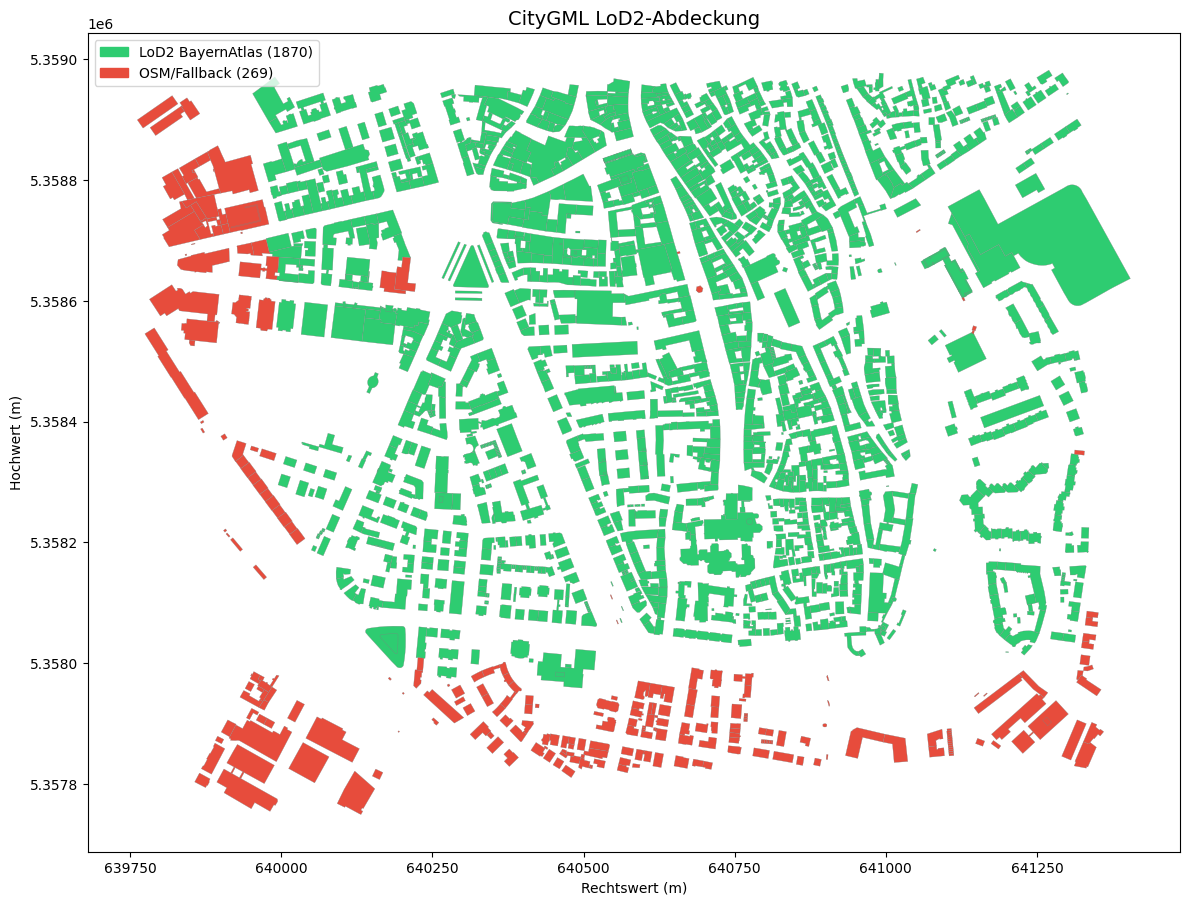

In [15]:
# Karte: LoD2-Gebäude (grün) vs. OSM-Fallback (rot)
if 'height_source' in gdf.columns:
    gdf_metric['lod2'] = gdf['height_source'] == 'citygml'

    fig, ax = plt.subplots(figsize=(12, 10))
    gdf_metric[gdf_metric['lod2']].plot(
        ax=ax, color='#2ecc71', edgecolor='grey', linewidth=0.2, label='LoD2 (BayernAtlas)'
    )
    gdf_metric[~gdf_metric['lod2']].plot(
        ax=ax, color='#e74c3c', edgecolor='grey', linewidth=0.2, label='OSM / Fallback'
    )

    p1 = mpatches.Patch(color='#2ecc71', label=f"LoD2 BayernAtlas ({gdf_metric['lod2'].sum()})")
    p2 = mpatches.Patch(color='#e74c3c', label=f"OSM/Fallback ({(~gdf_metric['lod2']).sum()})")
    ax.legend(handles=[p1, p2], loc='upper left')
    ax.set_title('CityGML LoD2-Abdeckung', fontsize=14)
    ax.set_xlabel('Rechtswert (m)')
    ax.set_ylabel('Hochwert (m)')
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.savefig(DATA_INTERIM.parent / 'output' / 'map_lod2_coverage.png', dpi=150)
    plt.show()
else:
    print('Spalte height_source fehlt – Phase 2 mit CityGML-Daten erneut ausführen.')

## 4 · Nutzungsklassen

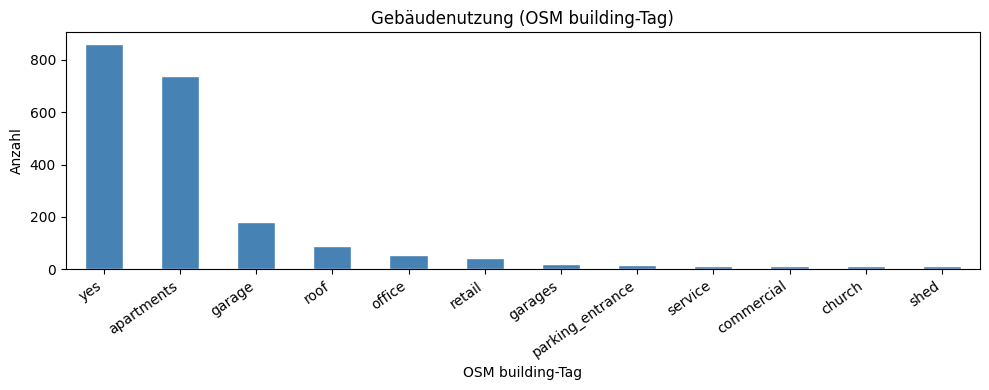

In [16]:
building_types = gdf['building'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 4))
building_types.plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('OSM building-Tag')
ax.set_ylabel('Anzahl')
ax.set_title('Gebäudenutzung (OSM building-Tag)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 5 · Grundflächen-Statistik (EPSG:25832)

In [17]:
gdf_metric['footprint_m2'] = gdf_metric.geometry.area
gdf_metric['levels_num']   = pd.to_numeric(gdf['levels'], errors='coerce').fillna(3)
gdf_metric['gfa_m2']       = gdf_metric['footprint_m2'] * gdf_metric['levels_num']

print('Grundfläche (Footprint):')
print(gdf_metric['footprint_m2'].describe().round(1).to_string())
print(f'\nGesamte Bruttogeschossfläche (GFA): {gdf_metric["gfa_m2"].sum():,.0f} m²')

Grundfläche (Footprint):
count     2139.0
mean       267.8
std        725.3
min          0.4
25%         71.1
50%        166.9
75%        285.1
max      28464.2

Gesamte Bruttogeschossfläche (GFA): 2,010,923 m²


## 6 · Dachart-Verteilung (CityGML + OSM-Fallback)

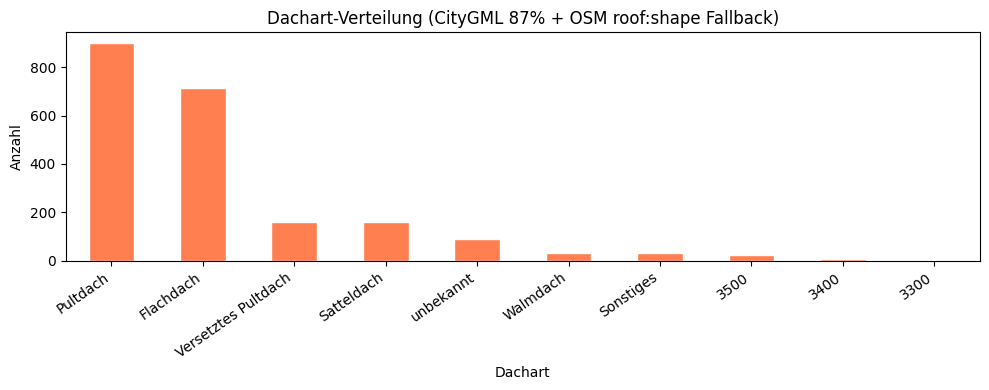

Dachform bekannt: 2048/2139 (96%)


In [18]:
ROOF_CODES = {
    '1000': 'Flachdach', '2100': 'Satteldach', '2200': 'Walmdach',
    '2300': 'Krüppelwalmdach', '2400': 'Mansarddach', '3100': 'Pultdach',
    '3200': 'Vers. Pultdach', '4000': 'Zeltdach', '5000': 'Kegeldach',
    '6000': 'Tonnendach', '9999': 'Sonstiges',
}

if 'roof_type' in gdf.columns:
    # Numerische Codes in Klartextnamen übersetzen (falls noch alte Daten vorliegen)
    roof_col = gdf['roof_type'].fillna('unbekannt').astype(str)
    roof_col = roof_col.map(lambda v: ROOF_CODES.get(v.strip(), v) if v.strip() else 'unbekannt')
    roof = roof_col.value_counts().head(10)
    bekannt = (roof_col != 'unbekannt').sum()

    fig, ax = plt.subplots(figsize=(10, 4))
    roof.plot.bar(ax=ax, color='coral', edgecolor='white')
    ax.set_xlabel('Dachart')
    ax.set_ylabel('Anzahl')
    ax.set_title('Dachart-Verteilung (CityGML 87% + OSM roof:shape Fallback)')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()
    print(f'Dachform bekannt: {bekannt}/{len(gdf)} ({bekannt/len(gdf)*100:.0f}%)')
else:
    print('Spalte roof_type fehlt – Phase 2 mit CityGML-Daten erneut ausführen.')

## 7 · Adressen, Denkmalschutz & Gebäudebeschreibung (OSM Extended Tags)

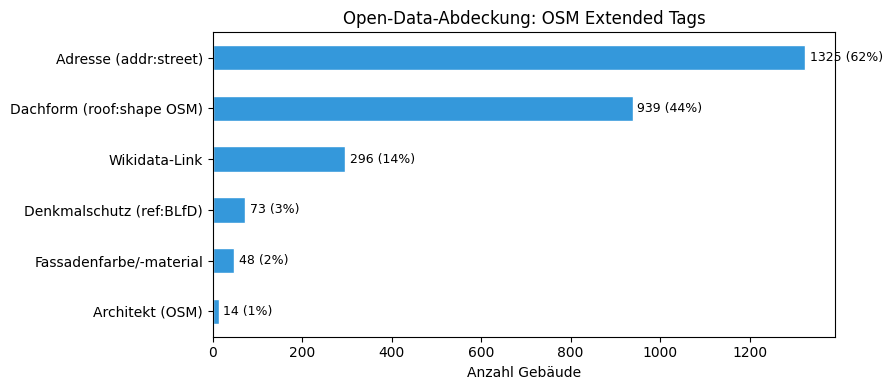

Denkmalgeschützte Gebäude (BLfD): 73
blfd_criteria
Baudenkmal    56
              17


In [19]:
coverage = {
    'Adresse (addr:street)':        gdf['addr_street'].astype(str).str.strip().ne('').sum() if 'addr_street' in gdf.columns else 0,
    'Denkmalschutz (ref:BLfD)':     gdf['ref_blfd'].astype(str).str.strip().ne('').sum() if 'ref_blfd' in gdf.columns else 0,
    'Wikidata-Link':                gdf['wikidata'].astype(str).str.strip().ne('').sum() if 'wikidata' in gdf.columns else 0,
    'Dachform (roof:shape OSM)':    gdf['osm_roof_shape'].astype(str).str.strip().ne('').sum() if 'osm_roof_shape' in gdf.columns else 0,
    'Fassadenfarbe/-material':      gdf['building_colour'].astype(str).str.strip().ne('').sum() if 'building_colour' in gdf.columns else 0,
    'Architekt (OSM)':              gdf['architect'].astype(str).str.strip().ne('').sum() if 'architect' in gdf.columns else 0,
}
cov = pd.Series(coverage).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
cov.plot.barh(ax=ax, color='#3498db', edgecolor='white')
for i, v in enumerate(cov.values):
    ax.text(v + 10, i, f'{v} ({v/len(gdf)*100:.0f}%)', va='center', fontsize=9)
ax.set_xlabel('Anzahl Gebäude')
ax.set_title('Open-Data-Abdeckung: OSM Extended Tags')
plt.tight_layout()
plt.show()

print(f'Denkmalgeschützte Gebäude (BLfD): {(gdf["ref_blfd"].astype(str).str.strip() != "").sum() if "ref_blfd" in gdf.columns else 0}')
if 'blfd_criteria' in gdf.columns:
    print(gdf.loc[gdf['ref_blfd'].astype(str).str.strip() != '', 'blfd_criteria'].value_counts().to_string())

## 8 · Wikidata-Anreicherung & Solarpotenzial (PVGIS)

In [20]:
import ifcopenshell
import ifcopenshell.util.element as ifc_util
from configs.settings import IFC_LOD200

if 'wd_baujahr' in gdf.columns:
    n_wd = (gdf['wikidata'].astype(str).str.strip() != '').sum()
    n_wd_year = (gdf['wd_baujahr'].astype(str).str.strip() != '').sum()
    print(f'Gebäude mit Wikidata-ID    : {n_wd}/{len(gdf)} ({n_wd/len(gdf)*100:.0f}%)')
    print(f'davon mit Baujahr ergänzt  : {n_wd_year}')

# Solarpotenzial aus der angereicherten IFC-Datei auslesen (Phase 7)
if IFC_LOD200.exists():
    f = ifcopenshell.open(str(IFC_LOD200))
    pv_yields, irrad = [], None
    for bldg in f.by_type('IfcBuilding'):
        psets = ifc_util.get_psets(bldg)
        sp = psets.get('Pset_SolarPotential')
        if sp:
            pv_yields.append(float(sp.get('PV_Yield_kWh_a', 0)))
            irrad = sp.get('SolarIrradiation_kWh_m2a', irrad)

    if pv_yields:
        fig, ax = plt.subplots(figsize=(9, 4))
        pd.Series(pv_yields).plot.hist(ax=ax, bins=30, color='#f1c40f', edgecolor='white')
        ax.set_xlabel('PV-Ertragspotenzial [kWh/a] je Gebäude')
        ax.set_ylabel('Anzahl Gebäude')
        ax.set_title(f'Solarpotenzial – Globalstrahlung {irrad:.0f} kWh/(m²·a), PVGIS SARAH-3')
        plt.tight_layout()
        plt.show()
        print(f'Gebäude mit Solardaten     : {len(pv_yields)}/{len(gdf)}')
        print(f'PV-Potenzial Quartier      : {sum(pv_yields)/1000:.0f} MWh/a')
    else:
        print('Keine Pset_SolarPotential-Daten in der IFC – 07_enrich_solar.py ausführen.')
else:
    print('IFC-Datei nicht gefunden – Phase 3+4 zuerst ausführen.')

Gebäude mit Wikidata-ID    : 296/2139 (14%)
davon mit Baujahr ergänzt  : 5
Keine Pset_SolarPotential-Daten in der IFC – 07_enrich_solar.py ausführen.
